In [1]:
api_url = "https://earth-search.aws.element84.com/v1"

from pystac_client import Client # pystac_client library ka use STAC API se connect hone aur data search karne ke liye hota hai.

client = Client.open(api_url) # client is now connected to the STAC API at the api_url. It can be used to search for and retrieve geospatial data.

collections = client.get_collections() #satellite datasets ka group.

for i in collections:
    print(i.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


In [2]:
collection_sentinel_2_l2a = "sentinel-2-l2a"

In [3]:
from shapely.geometry import Point 

point = Point(27.95, 36.20)  # Coordinates of a point on Rhodes(for our case study); Point(longitude, latitude)

# All the data we are dealing with right now is metadata, but even metadata can be quite bulky if a large number of scenes match our search. For this reason, we limit the search by the intersection of the point (by setting the parameter intersects) and assign the collection (by setting the parameter collections)

In [4]:
search = client.search(collections = [
                        collection_sentinel_2_l2a], # sirf Sentinel-2 dataset me search karo.
                        intersects = point, # jis satellite image ka area is point ko cover karta ho, usko return karo.
                        datetime = '2023-07-01/2023-08-31',  # 1st of July 2023 and 31st of August 2023
                        query = ["eo:cloud_cover<1"]
                        )  

print(search.matched()) 

11


In [5]:
items = search.item_collection()
items.save_object('rhodes_sentinel-2.json') #file is created in GeoJSON format. this file contains the metadata of the files that meet out criteria
print(len(items))

for i in items:
    print(i.id) #Each of the items contains information about the scene geometry

11
S2A_35SNA_20230827_0_L2A
S2B_35SNA_20230822_0_L2A
S2A_35SNA_20230817_0_L2A
S2B_35SNA_20230812_0_L2A
S2A_35SNA_20230807_0_L2A
S2B_35SNA_20230802_0_L2A
S2A_35SNA_20230728_0_L2A
S2B_35SNA_20230723_0_L2A
S2A_35SNA_20230718_0_L2A
S2B_35SNA_20230713_0_L2A
S2A_35SNA_20230708_0_L2A


In [6]:
item = items[0]
print(item.datetime)
print(item.geometry)
print(item.properties)

2023-08-27 09:00:21.327000+00:00
{'type': 'Polygon', 'coordinates': [[[27.290401625602243, 37.04621863329741], [27.23303872472207, 36.83882218126937], [27.011145718480538, 36.05673246264742], [28.21878905911668, 36.05053734221328], [28.234426643135546, 37.04015200857309], [27.290401625602243, 37.04621863329741]]]}
{'created': '2023-08-27T18:15:43.106Z', 'platform': 'sentinel-2a', 'constellation': 'sentinel-2', 'instruments': ['msi'], 'eo:cloud_cover': 0.955362, 'proj:epsg': 32635, 'mgrs:utm_zone': 35, 'mgrs:latitude_band': 'S', 'mgrs:grid_square': 'NA', 'grid:code': 'MGRS-35SNA', 'view:sun_azimuth': 144.36354987218, 'view:sun_elevation': 59.06665363921, 's2:degraded_msi_data_percentage': 0.0126, 's2:nodata_pixel_percentage': 12.146327, 's2:saturated_defective_pixel_percentage': 0, 's2:dark_features_percentage': 0.249403, 's2:cloud_shadow_percentage': 0.237454, 's2:vegetation_percentage': 6.073786, 's2:not_vegetated_percentage': 18.026696, 's2:water_percentage': 74.259061, 's2:unclassif

In [7]:
import pystac
items_loaded = pystac.ItemCollection.from_file("rhodes_sentinel-2.json") #to load the file we created in the previous step, we use the from_file method of the ItemCollection class. This method takes the path to the file as an argument and returns an ItemCollection object that contains all the items in the file.

So far we have only worked with metadata - but how can one get to the actual images of a satellite scene (the “assets” in the STAC nomenclature)? These can be reached via links that are made available through the item’s attribute assets

In [8]:
assets = items[-1].assets
print(assets.keys())

dict_keys(['aot', 'blue', 'coastal', 'granule_metadata', 'green', 'nir', 'nir08', 'nir09', 'red', 'rededge1', 'rededge2', 'rededge3', 'scl', 'swir16', 'swir22', 'thumbnail', 'tileinfo_metadata', 'visual', 'wvp', 'aot-jp2', 'blue-jp2', 'coastal-jp2', 'green-jp2', 'nir-jp2', 'nir08-jp2', 'nir09-jp2', 'red-jp2', 'rededge1-jp2', 'rededge2-jp2', 'rededge3-jp2', 'scl-jp2', 'swir16-jp2', 'swir22-jp2', 'visual-jp2', 'wvp-jp2'])


In [9]:
for key, asset in assets.items():
    print(f'{key}: {asset.title}')

aot: Aerosol optical thickness (AOT)
blue: Blue (band 2) - 10m
coastal: Coastal aerosol (band 1) - 60m
granule_metadata: None
green: Green (band 3) - 10m
nir: NIR 1 (band 8) - 10m
nir08: NIR 2 (band 8A) - 20m
nir09: NIR 3 (band 9) - 60m
red: Red (band 4) - 10m
rededge1: Red edge 1 (band 5) - 20m
rededge2: Red edge 2 (band 6) - 20m
rededge3: Red edge 3 (band 7) - 20m
scl: Scene classification map (SCL)
swir16: SWIR 1 (band 11) - 20m
swir22: SWIR 2 (band 12) - 20m
thumbnail: Thumbnail image
tileinfo_metadata: None
visual: True color image
wvp: Water vapour (WVP)
aot-jp2: Aerosol optical thickness (AOT)
blue-jp2: Blue (band 2) - 10m
coastal-jp2: Coastal aerosol (band 1) - 60m
green-jp2: Green (band 3) - 10m
nir-jp2: NIR 1 (band 8) - 10m
nir08-jp2: NIR 2 (band 8A) - 20m
nir09-jp2: NIR 3 (band 9) - 60m
red-jp2: Red (band 4) - 10m
rededge1-jp2: Red edge 1 (band 5) - 20m
rededge2-jp2: Red edge 2 (band 6) - 20m
rededge3-jp2: Red edge 3 (band 7) - 20m
scl-jp2: Scene classification map (SCL)
swi

In [10]:
print(assets['thumbnail'].href ) #before the wildfire
print(items[0].assets['thumbnail'].href ) 

https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/thumbnail.jpg
https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/thumbnail.jpg


Till now we connected  to STAC, selected our satellite, gave the coordinates to get the exact surroundings of Rhodes. Then we narrowed down the search near where the wildfire is, saved those data. Data saved is meta data. We then loaded the saved file to look into images (assets)

In [11]:
import rioxarray as rxr
red_href = assets['red'].href
red = rxr.open_rasterio(red_href)
print(red)

<xarray.DataArray (band: 1, y: 10980, x: 10980)> Size: 241MB
[120560400 values with dtype=uint16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 88kB 4.1e+06 4.1e+06 4.1e+06 ... 3.99e+06 3.99e+06
  * x            (x) float64 88kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0


In [ ]:
red.rio.to_raster('red.tif') #save 

In [40]:
red_subset  = red.rio.clip_box(
    minx=560900,
    miny=3995000,
    maxx=570900,
    maxy=4015000)

#.rio rioxarray accessor hai, jo sirf geospatial kaam ke liye use hota hai

In [ ]:
red_subset.rio.to_raster("red_subset.tif")

In [15]:
rhodes_visual_href = item.assets["visual"].href  # true color image
print(rhodes_visual_href)

https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/TCI.tif


In [16]:
print(red) 

<xarray.DataArray (band: 1, y: 10980, x: 10980)> Size: 241MB
[120560400 values with dtype=uint16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 88kB 4.1e+06 4.1e+06 4.1e+06 ... 3.99e+06 3.99e+06
  * x            (x) float64 88kB 5e+05 5e+05 5e+05 ... 6.098e+05 6.098e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0


The output tells us that we are looking at an xarray.DataArray, with 1 band, 10980 rows, and 10980 columns.

The term coordinates refers to spatial coordinates like x and y but also the band coordinate.

In [17]:
print(red.rio.crs) #coordinate reference system
print(red.rio.nodata) #missing value
print(red.rio.bounds()) #minimum and maximum coordinates covered by the raster
print(red.rio.width) #it is a square grid of 10,980 rows.
print(red.rio.height) #it is a square grid of 10,980 columns.
print(red.rio.resolution()) #spatial resolution

EPSG:32635
0
(499980.0, 3990240.0, 609780.0, 4100040.0)
10980
10980
(10.0, -10.0)


In [ ]:
red.values #red.values is the actual grid of numbers behind the raster image, like the raw pixels in a photo.

---

# Visual Representation

```text
Raster (Band × Height × Width) (DataArray)

Band 0
│
├── Row 0 ──► [Pixel0] [Pixel1] [Pixel2] ... [PixelW-1]
├── Row 1 ──► [Pixel0] [Pixel1] [Pixel2] ... [PixelW-1]
├── Row 2 ──► [Pixel0] [Pixel1] [Pixel2] ... [PixelW-1]
│
└── ...
```

Or, showing the dimensions more explicitly:

```text
                    Width (Columns)
              ─────────────────────────►

Band 0
│
├── Row 0   [ 0 ][ 0 ][ 0 ] ... [8888][9075][8139]
├── Row 1   [ 0 ][ 0 ][ 0 ] ... [10444][10358][8669]
├── Row 2   [ 0 ][ 0 ][ 0 ] ... [10346][10659][9168]
│
▼
Height (Rows)
```

Example with a smaller array

```python
raster = np.array([
    [
        [11, 12, 13, 14],
        [21, 22, 23, 24],
        [31, 32, 33, 34]
    ]
])
```

Its shape is:

```python
(1, 3, 4)
```

---

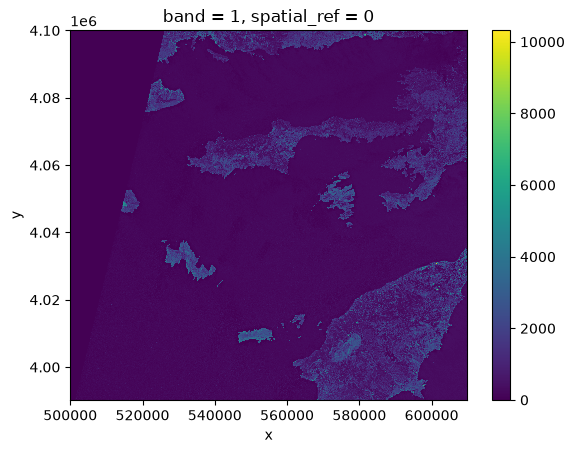

In [31]:
import matplotlib 
red.plot()

In [ ]:
rhodes_red_80  = rxr.open_rasterio("data/sentinel2/red.tif", overview_level=2) #cloud-optimized GeoTIFFs(COGS), typically include multiple lower-resolution versions of the original image, called “overviews”, in the same file. This allows us to avoid downloading high-resolution images when only quick previews are required
print(rhodes_red_80.rio.resolution())

(79.97086671522214, -79.97086671522214)


Overviews:
----------
Overviews are often computed using powers of 2 as down-sampling (or zoom) factors. So, typically, the first level overview (index 0) corresponds to a zoom factor of 2, the second level overview (index 1) corresponds to a zoom factor of 4, and so on. Here, we open the third level overview (index 2, zoom factor 8) and check that the resolution is about 80 m:


Then: 10 m resolution: Each pixel represents a 10 × 10 m area, so there are many more pixels covering the same geographic extent.

Now: 80 m resolution: Each pixel represents an 80 × 80 m area, so there are far fewer pixels.

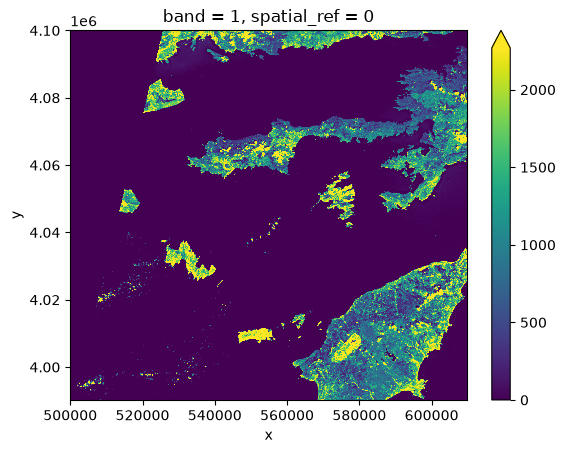

In [24]:
rhodes_red_80.plot(robust=True) #Ye outliers (bahut zyada ya bahut kam values) ko ignore karke color scale choose karta hai.

vmin=100: Matlab 100 se chhoti values ko same minimum color (darkest/lowest color) dikhao.


vmax=2000: Matlab 2000 se badi values ko same maximum color (brightest/highest color) dikhao.

Note: band=1 in the image title refers to the ordering of all the bands in the DataArray

--------------------------------------------------------------------------------------------

View Raster Coordinate Reference System (CRS) in Python
------------------------------------

In [25]:
print(rhodes_red_80.rio.crs)

EPSG:32635


In [28]:
print(rhodes_red_80.rio.crs.to_epsg())

32635


To get more information like units, we use pyroj library

In [32]:
from pyproj import CRS
epsg = rhodes_red_80.rio.crs.to_epsg()
crs = CRS(epsg)
crs

<Projected CRS: EPSG:32635>
Name: WGS 84 / UTM zone 35N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 24°E and 30°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Bulgaria. Central African Republic. Democratic Republic of the Congo (Zaire). Egypt. Estonia. Finland. Greece. Latvia. Lesotho. Libya. Lithuania. Moldova. Norway. Poland. Romania. Russian Federation. Sudan. Svalbard. Türkiye (Turkey). Uganda. Ukraine.
- bounds: (24.0, 0.0, 30.0, 84.0)
Coordinate Operation:
- name: UTM zone 35N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

An useful attribute is area_of_use, which shows the geographic bounds that the CRS is intended to be used.

In [36]:
crs.area_of_use

AreaOfUse(west=24.0, south=0.0, east=30.0, north=84.0, name='Between 24°E and 30°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Bulgaria. Central African Republic. Democratic Republic of the Congo (Zaire). Egypt. Estonia. Finland. Greece. Latvia. Lesotho. Libya. Lithuania. Moldova. Norway. Poland. Romania. Russian Federation. Sudan. Svalbard. Türkiye (Turkey). Uganda. Ukraine.')

# Summary

| Term | Meaning  |
|------|---------------------|
| **Projection** | Earth ko flat map par dikhane ka mathematical tareeka. |
| **UTM** | Earth ko 60 zones mein divide karta hai. |
| **Zone 35N** | 24°E–30°E longitude aur Northern Hemisphere ke liye projection. |
| **Datum (WGS84)** | Earth ka reference model jisse coordinates calculate hote hain. |
| **Axis** | Easting (X) aur Northing (Y), dono meter mein. |
| **Coordinate Operation** | Transverse Mercator projection jo latitude-longitude ko meter-based coordinates mein convert karta hai. |
| **Area of Use** | Sirf apne zone ke andar sabse zyada accurate hota hai. |

In [37]:
rhodes_red_80.rio.crs.linear_units

'metre'

Calculate Raster Statistics

In [44]:
print(rhodes_red_80.min()) # array(0,dtype=unit16) min = 0
print(rhodes_red_80.max()) # array(20598,dtype=unit16) max = 20598
print(rhodes_red_80.mean())# array(294.09450759,dtype=unit16) mean = 294.09450759
print(rhodes_red_80.std()) # array(735.51761417,dtype=unit16) std = 735.51761417

<xarray.DataArray ()> Size: 2B
array(0, dtype=uint16)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0
<xarray.DataArray ()> Size: 2B
array(20598, dtype=uint16)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0
<xarray.DataArray ()> Size: 8B
array(294.09450759)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0
<xarray.DataArray ()> Size: 8B
array(735.51761417)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_off

In [46]:
print(rhodes_red_80.min().item())
print(rhodes_red_80.max().item())
print(rhodes_red_80.mean().item())
print(rhodes_red_80.std().item())

0
20598
294.09450759072723
735.5176141732363


In [ ]:
# we can calculate the percentage using quantile function, and numpy 

# 1. Quantile function 

print(rhodes_red_80.quantile([0.25, 0.75]))

# 2. Numpy version 
import numpy as np 
print(np.percentile(rhodes_red_80, [25,75]))

#Output in both the cases: [ 1. 54.]

<xarray.DataArray (quantile: 2)> Size: 16B
array([ 1., 54.])
Coordinates:
  * quantile  (quantile) float64 16B 0.25 0.75
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0
[ 1. 54.]


### Working with missing data 

Raster data often has a “nodata” associated with it and for raster datasets read in by rioxarray. This is a value assigned to pixels where data is missing or no data were collected. The most common example is missing data at the edges of rasters.

In [52]:
rhodes_red_80.rio.nodata

#it means that 0 is the NoData value defined in the raster's metadata.

np.uint16(0)

In [53]:
rhodes_masked_80= rxr.open_rasterio("data/sentinel2/red.tif", masked = True, overview_level = 2)

# When used masked = True, pixels equal to the raster's NoData value (e.g., 0) are converted to NaN.

In [63]:
print(f'Data with "0" as No data: {rhodes_red_80.min().item()} \n')
print(f'Data with "Nan" as No data min: {rhodes_masked_80.min().item()} \n')
print(f'Data with "0" as No data: {rhodes_red_80.max().item()} \n')
print(f'Data with "Nan" as No data max: {rhodes_masked_80.max().item()} \n')
print(f'Data with "0" as No data: {rhodes_red_80.mean().item()} \n')
print(f'Data with "Nan" as No data mean: {rhodes_masked_80.mean().item()} \n')
print(f'Data with "0" as No data: {rhodes_red_80.std().item()} \n')
print(f'Data with "Nan" as No data std: {rhodes_masked_80.std().item()} \n')

Data with "0" as No data: 0 

Data with "Nan" as No data min: 1.0 

Data with "0" as No data: 20598 

Data with "Nan" as No data max: 20598.0 

Data with "0" as No data: 294.09450759072723 

Data with "Nan" as No data mean: 334.59478759765625 

Data with "0" as No data: 735.5176141732363 

Data with "Nan" as No data std: 775.8447265625 



| Statistic | NoData = 0 | NoData = NaN |
|-----------|-----------:|-------------:|
| Minimum | 0 | 1 |
| Maximum | 20598 | 20598.0 |
| Mean | 294.09450759 | 334.59478759765625  |
| Standard Deviation | 735.51761417 | 775.8447265625 |

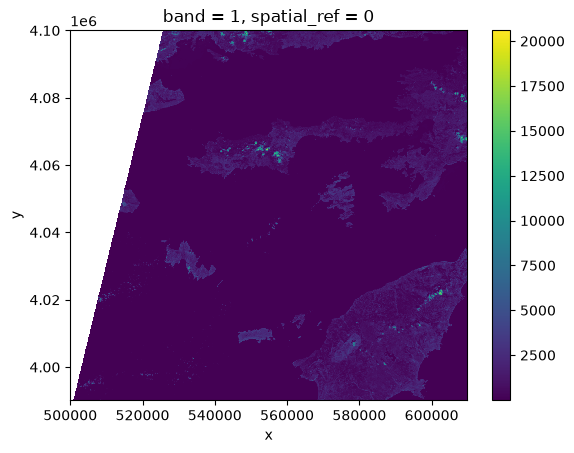

In [65]:
rhodes_masked_80.plot()

### Raster Bands

The visual asset in the Sentinel-2 scene is a multiband asset. It is helpful to visualize the true-color image of the region. This is provided as a multi-band raster – a raster dataset that contains more than one band.

In [67]:
rhodes_visual = rxr.open_rasterio("data/sentinel2/visual.tif", overview_level=2)
rhodes_visual

<xarray.DataArray (band: 3, y: 1373, x: 1373)> Size: 6MB
[5655387 values with dtype=uint8]
Coordinates:
  * band         (band) int64 24B 1 2 3
  * y            (y) float64 11kB 4.1e+06 4.1e+06 4.1e+06 ... 3.99e+06 3.99e+06
  * x            (x) float64 11kB 5e+05 5.001e+05 ... 6.097e+05 6.097e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0

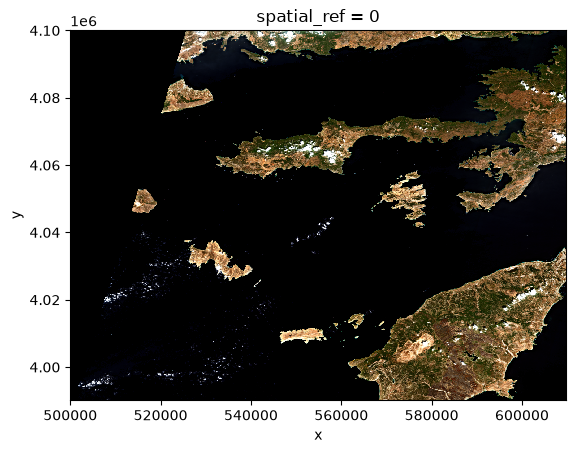

In [69]:
rhodes_visual.plot.imshow()

# .plot() = Tum decide karo kaunsa plot best hai.
# .plot.imshow() = Mujhe image hi plot karni hai.

DataArray.plot.imshow() automatically assume karta hai ki agar DataArray mein 3 channels(bands) hain, to woh RGB image hai. Isliye woh pehle channel ko Red, doosre ko Green, aur teesre ko Blue maan kar color image display karta hai.

3 bands → imshow() automatically RGB image bana deta hai.

More than 3 bands → imshow() ko khud nahi pata kaun se bands use karne hain, hence it displays false-color image.

False-color image → RGB channels mein alag spectral bands assign karke specific features (jaise vegetation ya water) ko highlight kiya jata hai.

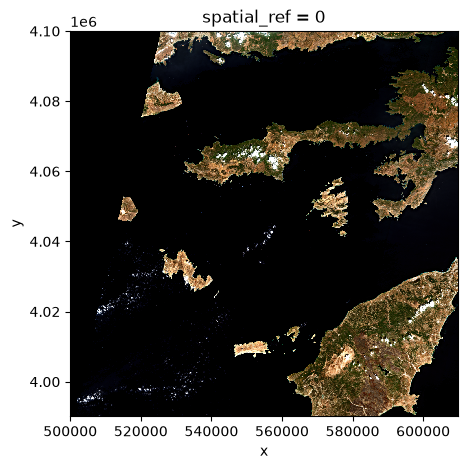

In [ ]:
rhodes_visual.plot.imshow(size = 5, aspect = 1)

# aspect ka matlab hai image ko kis proportion mein dikhana hai. Yeh decide karta hai ki image stretch hogi ya apni original shape maintain karegi.
# size=5 → Figure ka base size 5 units (usually inches) hoga.
# aspect=1 → Width : Height = 1 : 1. Figure square shape mein banegi.